In [6]:
import os
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:

# Directory containing the chunked files
input_dir = "../../DataPreprocessing/outputs/chunks"

# Get a sorted list of all chunk files
chunk_files = sorted(glob.glob(os.path.join(input_dir, "cleaned_courses_final_chunk_*.pkl")))

# Read all chunks and concatenate into a single DataFrame
df_list = [pd.read_pickle(f) for f in chunk_files]
df_final = pd.concat(df_list, ignore_index=True)

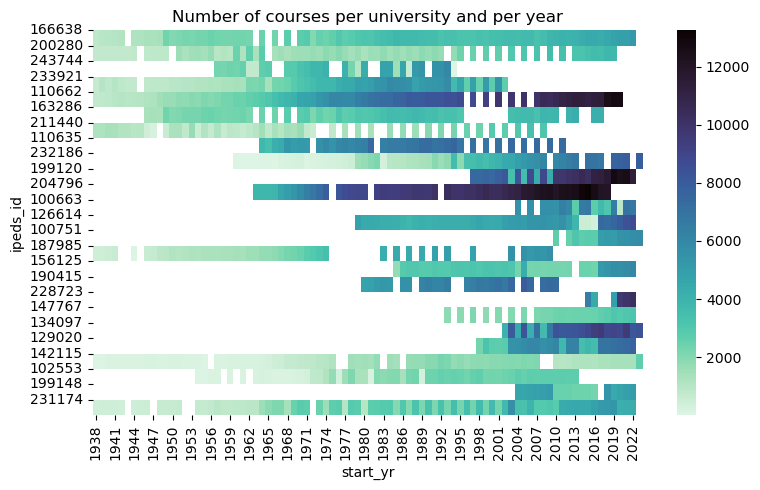

In [10]:
# distribution of courses per year per university NOT per cat_type

fig, axes_orig = plt.subplots(figsize=(8, 5), nrows=1, ncols=1)
axes = axes_orig

df = df_final.copy()

# distribution of courses per year per university per cat_type
aux_ = df.groupby(["ipeds_id", "cat_type", "start_yr"]).size()
min_val = aux_.min().min()
max_val = aux_.max().max()

full_index = df["ipeds_id"].unique()

##data to identify the number of courses per unique catalog
data_ = df.groupby(["ipeds_id", "start_yr"]).size()

sns.heatmap(
    # in AI_orig I tried to group words based on historical evolution of utilization. I tried to plot in same order to find visual clusters/patterns
    data_.unstack()
    .reindex(columns=range(1938, 2024), fill_value=np.nan)
    .reindex(index=full_index, fill_value=np.nan),
    cmap=sns.color_palette("mako_r", as_cmap=True),
    vmax=max_val,
    vmin=min_val,
    ax=axes,
)
axes.set_yticks(range(len(full_index)))
axes.set_yticklabels(full_index)

plt.title("Number of courses collected per university and per year")

plt.tight_layout()

output_path = "../../DataPreprocessing/outputs"
# Full path for the saved figure
fig_path = os.path.join(output_path, "heatmap_courses_per_year_per_university.png")

# Save the figure
plt.savefig(fig_path, dpi=300, bbox_inches='tight')